In [5]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


--- Generating Synthetic Time Series Data ---
Generated 'Covariate_1_lag2' with a lag of 2 steps.
Generated 'Covariate_2_lag4' with a lag of 4 steps.
Generated 'Covariate_3_lag6' with a lag of 6 steps.
Generated 'Covariate_4_lag8' with a lag of 8 steps.
Generated 'Covariate_5_lag10' with a lag of 10 steps.
Generated 'Covariate_6_lag12' with a lag of 12 steps.
Generated 'Covariate_7_lag14' with a lag of 14 steps.

Successfully saved the data to 'data/synthetic/synthetic_sinus.csv'
Preview of the generated data:


,Target,Date,Covariate_1_lag2,Covariate_2_lag4,Covariate_3_lag6,Covariate_4_lag8,Covariate_5_lag10,Covariate_6_lag12,Covariate_7_lag14
0,0.000000,2020-01-01,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,0.310518,2020-01-02,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,0.590337,2020-01-03,0.033929,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,0.811792,2020-01-04,0.262655,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,0.952989,2020-01-05,0.569204,0.086117,0.000000,0.000000,0.0,0.0,0.0
5,0.999969,2020-01-06,0.764798,0.425080,0.000000,0.000000,0.0,0.0,0.0
6,0.948087,2020-01-07,0.894159,0.626893,-0.052742,0.000000,0.0,0.0,0.0
7,0.802472,2020-01-08,0.953234,0.695075,0.300505,0.000000,0.0,0.0,0.0
8,0.577521,2020-01-09,0.935610,0.882249,0.583922,0.146803,0.0,0.0,0.0
9,0.295473,2020-01-10,0.791539,0.957541,0.903733,0.300345,0.0,0.0,0.0



--- Visualizing the Time Series ---


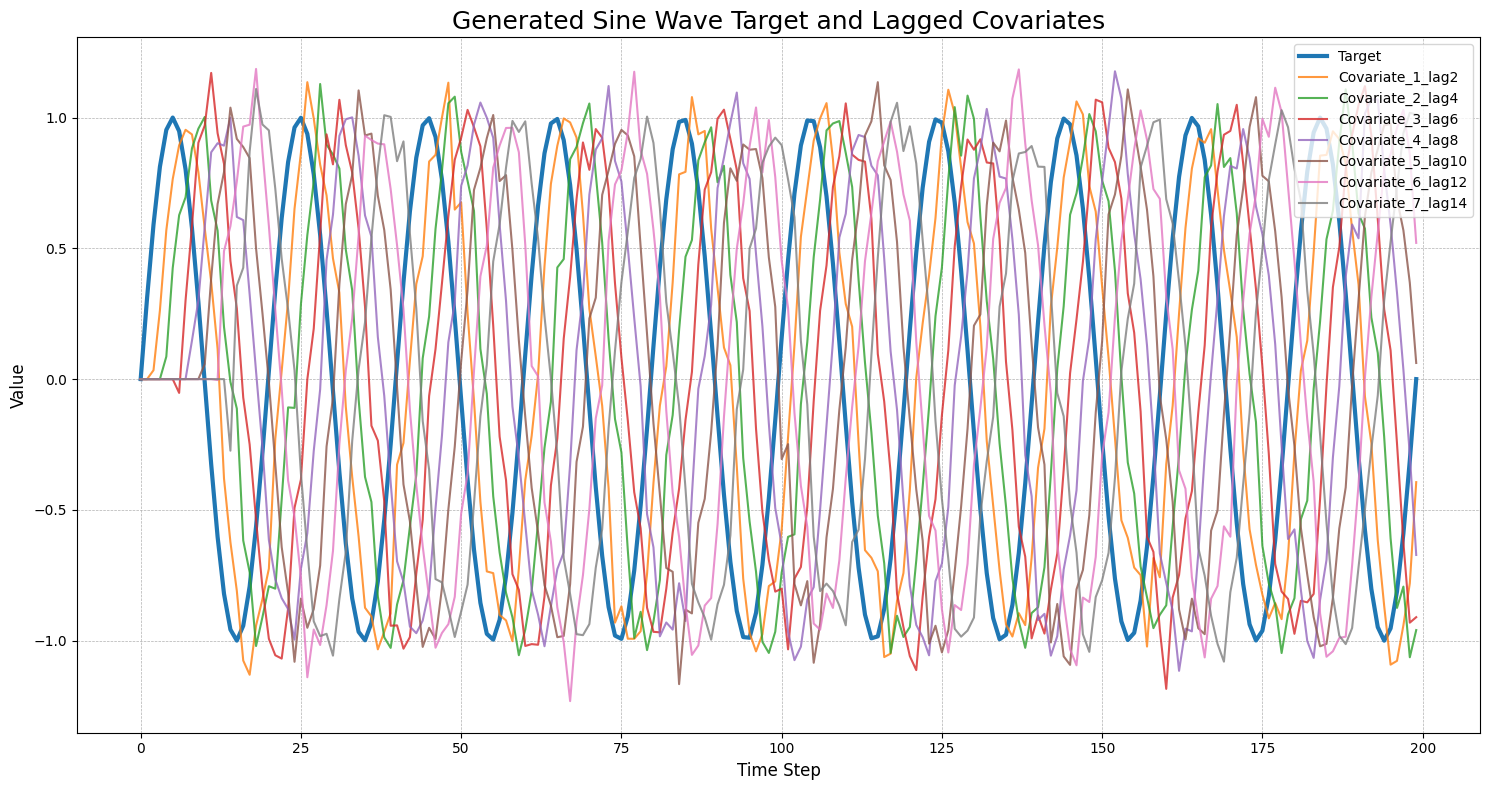

In [6]:
# --- 1. Define Parameters ---
n_timestamps = 200
n_covariates = 7
output_filename = 'data/synthetic/synthetic_sinus.csv'

print("--- Generating Synthetic Time Series Data ---")

# --- 2. Generate the Target Sine Wave ---
# Create a time vector for two full cycles (0 to 4*pi)
time_vector = np.linspace(0, 20 * np.pi, n_timestamps)
target_wave = np.sin(time_vector)

# Create a dictionary to hold all our series
data_dict = {'Target': target_wave, 'Date': pd.date_range(start='2020-01-01', periods=n_timestamps, freq='D')}

# --- 3. Generate the Lagged Covariates ---
# We will use small, increasing lags for each covariate
for i in range(1, n_covariates + 1):
    lag = i * 2  # e.g., lags of 2, 4, 6, 8, 10, 12, 14
    covariate_name = f'Covariate_{i}_lag{lag}'
    
    # Create an empty array for the new lagged series
    lagged_series = np.full(n_timestamps, np.nan)
    
    # Copy the shifted target wave into the new series
    # The first 'lag' values will remain NaN (Not a Number)
    lagged_series[lag:] = target_wave[:-lag]
    lagged_series += np.random.normal(0, 0.08, n_timestamps)

    data_dict[covariate_name] = lagged_series
    print(f"Generated '{covariate_name}' with a lag of {lag} steps.")

# --- 4. Create a Pandas DataFrame ---
df = pd.DataFrame(data_dict)
df = df.fillna(0)
# --- 5. Save the Data to a .csv File ---
try:
    df.to_csv(output_filename, index=False)
    print(f"\nSuccessfully saved the data to '{output_filename}'")
    # Display the first few rows to show the lagged NaNs
    print("Preview of the generated data:")
    display(df.head(10))
except Exception as e:
    print(f"\nError saving file: {e}")

# --- 6. Visualize the Data ---
print("\n--- Visualizing the Time Series ---")
fig, ax = plt.subplots(figsize=(15, 8))

# Plot each column in the DataFrame
for column in df.columns:
    if column == 'Date':
        continue
    # Use a thicker line for the target to make it stand out
    linewidth = 3 if column == 'Target' else 1.5
    alpha = 1.0 if column == 'Target' else 0.8
    
    ax.plot(df.index, df[column], label=column, linewidth=linewidth, alpha=alpha)

# Formatting the plot for clarity
ax.set_title('Generated Sine Wave Target and Lagged Covariates', fontsize=18)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Show the plot
plt.show()